# EDM feasibility check





## Imports

In [15]:
import os, time, math
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

# -----------------------
# CPU controls (adjust!)
# -----------------------
CPU_THREADS = int(os.environ.get("OMP_NUM_THREADS", "8"))
torch.set_num_threads(CPU_THREADS)
# torch.set_num_interop_threads(1)

device = torch.device("cpu")

def seed_all(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_all(42)


## Loading the datasets
Defining some testing variables and loading the pre-processed dataset

In [3]:
# Adjust these like in your notebook
ticker = "AAPL"
start_date = "2010-01-01"
end_date   = "2024-12-31"
sequence_length = 252
validation_ratio = 0.2

# CPU feasibility and training parameters
batch_size = 32  # CPU-friendly starting point
MAX_TRAIN_WINDOWS = 5000  # change to 1000 / 10000 depending on speed

MAX_STEPS = 5000  # feasibility: 200–1000
LOG_EVERY = 200

In [4]:
# Match your repo layout from the notebook
p1 = Path.cwd().parent
dataset_dir = p1 / "data"
sys_path_added = False

import sys
sys.path.insert(0, str(dataset_dir))  # so yahoo_data.py is importable
from yahoo_data import FinancialDataset  # same as your CSDI test

In [5]:
df = pd.read_csv(f"../data/{ticker}_{start_date}_{end_date}_processed.csv")

full_dataset = FinancialDataset(df, seq_len=sequence_length)

# FEASIBILITY: restrict to small subset to measure step speed
train_len = min(len(full_dataset), MAX_TRAIN_WINDOWS)
train_dataset = Subset(full_dataset, range(0, train_len))

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,   # set >0 on HPC if it helps
    pin_memory=False
)

# Infer target_dim from one batch (matches your CSDI_Financial target_dim=5)
sample = next(iter(train_loader))
x0 = sample["observed_data"]  # expected shape: [B, K, L]
target_dim = x0.shape[1]
print("target_dim:", target_dim, "seq_len:", x0.shape[2], "train_windows:", train_len)


target_dim: 5 seq_len: 252 train_windows: 3521


In [6]:
# print(sample)

# Conditional Smaller Network
Some information about the following chunk of code:
* `GroupNorm`: is preferred to `BatchNorm`, because with smaller batch as in the case of CPU running, this avoid unstable training. 8 groups is a standard choice.
* kernel size: is 3 and is the minimum in order to avoid excessive window lenght, which anyway should overlap.
* 3K channels: derive from the fact that you add `x_noisy`, `cond_values = x * mask`, and `mask`, all of them are 1K
* `base_ch=64`: is small enough to train on CPU, but it shouldn't underfit, and it keeps `GroupNorm` clean
* `n_blocks=4`: the model should be strong enough to 'understand' while not excessively comple to slow down excessively the training.

In [7]:
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: [B] (float)
        half = self.dim // 2
        freqs = torch.exp(
            torch.linspace(math.log(1.0), math.log(1000.0), half, device=t.device)
        )
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        if self.dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, ch: int, tdim: int):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, ch)
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, ch)
        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1)
        self.tproj = nn.Linear(tdim, ch)

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.tproj(F.silu(t_emb))[:, :, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return x + h

class TinyCondNet1D(nn.Module):
    """
    Input channels:
      - noisy series: K
      - conditioned values (observed): K
      - mask: K
    Total = 3K
    Output: K (predicted residual for EDM denoised estimate)
    """
    def __init__(self, K: int, base_ch: int = 64, tdim: int = 128, n_blocks: int = 4):
        super().__init__()
        self.time_emb = SinusoidalTimeEmb(tdim)
        self.time_mlp = nn.Sequential(
            nn.Linear(tdim, tdim),
            nn.SiLU(),
            nn.Linear(tdim, tdim),
        )

        in_ch = 3 * K
        self.in_conv = nn.Conv1d(in_ch, base_ch, 3, padding=1)
        self.blocks = nn.ModuleList([ResBlock1D(base_ch, tdim) for _ in range(n_blocks)])
        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv1d(base_ch, K, 3, padding=1)

    def forward(self, x_in, c_noise):
        # x_in: [B, 3K, L], c_noise: [B]
        t = self.time_mlp(self.time_emb(c_noise))
        h = self.in_conv(x_in)
        for b in self.blocks:
            h = b(h, t)
        h = self.out_conv(F.silu(self.out_norm(h)))
        return h


## EDM Wrapper
Because in EDM we train the network to return a slighly noisy data, then we need to make some adjustments.
Some specific details:
* `sigma_data = 0.5`: typical scale (std dev) is often around 0.5 to 1.0.
* refers to the specific EDM paper for specific understanding of `c_in`, `c_skip`, `c_out`, but roughtly:
    * c_in: input scaling
    * c_skip: skip connection weight
    * c_out: network output scaling
    * c_noise: te division by 4 is a normalization trick used in EDM impelementations so that c_noise stays in a smaller numeric range.
* `P_std` and `P_mean` are 1.2 because this is a standard choise that produces a wide range of values
* `sigma_min` and `sigma_max`: are the typical values for VE, refer to Yang Song's paper.

In [8]:
class EDMWrapper(nn.Module):
    def __init__(self, net: nn.Module, sigma_data: float = 0.5):
        super().__init__()
        self.net = net
        self.sigma_data = sigma_data

    def forward(self, x_noisy, sigma, cond_values, cond_mask):
        """
        x_noisy: [B,K,L]
        sigma:   [B] noise levels
        cond_values: [B,K,L] (x * cond_mask)
        cond_mask:   [B,K,L] in {0,1}

        Returns: denoised estimate x_hat [B,K,L]
        """
        sigma_data = self.sigma_data
        sigma2 = sigma * sigma
        sd2 = sigma_data * sigma_data

        c_skip  = sd2 / (sigma2 + sd2)
        c_out   = (sigma * sigma_data) / torch.sqrt(sigma2 + sd2)
        c_in    = 1.0 / torch.sqrt(sigma2 + sd2)
        c_noise = torch.log(sigma) / 4.0

        # Scale continuous channels with c_in, keep mask unscaled
        x_in = torch.cat([
            (c_in[:, None, None] * x_noisy),
            (c_in[:, None, None] * cond_values),
            cond_mask
        ], dim=1)

        model_out = self.net(x_in, c_noise)  # [B,K,L]
        x_hat = (c_skip[:, None, None] * x_noisy) + (c_out[:, None, None] * model_out)
        return x_hat

def edm_loss_masked(edm: EDMWrapper, x, base_obs_mask, gt_mask=None,
                    p_drop=0.2, sigma_min=0.01, sigma_max=50.0,
                    P_mean=-1.2, P_std=1.2):
    """
    x: [B,K,L] full data (standardized)
    base_obs_mask: [B,K,L] indicates data exists
    gt_mask: [B,K,L] optional: your dataset may provide this (withheld positions)
    """

    B = x.shape[0]

    # 1) Build conditioning and target masks
    if gt_mask is not None:
        # Assume gt_mask=1 means "to impute" and a mask is provided
        target_mask = gt_mask.float().clamp(0, 1)
        cond_mask = (base_obs_mask.float() - target_mask).clamp(0, 1)
    else:
        # Artificially withhold some observed points for feasibility
        # a mask is created
        drop = (torch.rand_like(base_obs_mask.float()) < p_drop).float()
        cond_mask = (base_obs_mask.float() * (1.0 - drop)).clamp(0, 1)
        target_mask = (base_obs_mask.float() - cond_mask).clamp(0, 1)

    cond_values = x * cond_mask

    # 2) Sample sigma (log-normal) and clamp
    rnd = torch.randn(B, device=x.device)
    sigma = torch.exp(rnd * P_std + P_mean).clamp(sigma_min, sigma_max)  # [B]

    # 3) Add noise
    noise = torch.randn_like(x)
    x_noisy = x + sigma[:, None, None] * noise

    # 4) EDM denoise
    x_hat = edm(x_noisy, sigma, cond_values, cond_mask)

    # 5) EDM loss weighting
    sigma_data = edm.sigma_data
    weight = (sigma*sigma + sigma_data*sigma_data) / ((sigma*sigma_data)**2)  # [B]

    mse = (x_hat - x) ** 2
    # Only score on target (imputed) positions
    numer = (weight[:, None, None] * mse * target_mask).sum()
    denom = target_mask.sum().clamp(min=1.0)
    return numer / denom


# Training
This loop is not trying to fully train EDM it is designed for the feasibility questions:
* Does the EDM objective run stably end-to-end?
* How fast is one optimization step?

The choice of AdamW is just because it is stable on small batch sizes and is less prone than manual L2 with Adam, we are also applying light regularisation.

In [ ]:
net = TinyCondNet1D(K=target_dim, base_ch=64, tdim=128, n_blocks=4).to(device)
edm = EDMWrapper(net, sigma_data=0.5).to(device)

opt = torch.optim.AdamW(edm.parameters(), lr=2e-4, weight_decay=1e-4)

edm.train()

t0 = time.perf_counter()
step_times = []
steps_done = 0

loader_iter = iter(train_loader)

historic_loss = []

for step in range(1, MAX_STEPS + 1):
    try:
        batch = next(loader_iter)
    except StopIteration:
        loader_iter = iter(train_loader)
        batch = next(loader_iter)

    x = batch["observed_data"].to(device).float()         # [B,K,L]
    obs_mask = batch["observed_mask"].to(device).float()  # [B,K,L]
    gt_mask = batch.get("gt_mask", None)
    if gt_mask is not None:
        gt_mask = gt_mask.to(device)

    t_step0 = time.perf_counter()
    opt.zero_grad(set_to_none=True)

    loss = edm_loss_masked(
        edm, x, obs_mask, gt_mask=gt_mask,
        p_drop=0.2,
        sigma_min=0.01, sigma_max=50.0,
        P_mean=-1.2, P_std=1.2
    )

    historic_loss.append(loss.item())

    loss.backward()
    torch.nn.utils.clip_grad_norm_(edm.parameters(), 1.0)
    opt.step()

    t_step1 = time.perf_counter()
    step_times.append(t_step1 - t_step0)
    steps_done += 1

    if step % LOG_EVERY == 0:
        avg = sum(step_times[-LOG_EVERY:]) / LOG_EVERY
        ex_per_s = batch_size / avg
        print(f"step {step:4d} | loss {loss.item():.4f} | {avg:.3f}s/step | {ex_per_s:.2f} ex/s")

t1 = time.perf_counter()
print("Total time:", t1 - t0, "sec")
print("Mean step time:", float(np.mean(step_times)), "sec")


step  200 | loss 1.5862 | 0.067s/step | 480.49 ex/s
step  400 | loss 1.1307 | 0.055s/step | 583.29 ex/s
step  600 | loss 1.2009 | 0.057s/step | 556.96 ex/s
step  800 | loss 1.1855 | 0.060s/step | 528.98 ex/s
step 1000 | loss 1.1443 | 0.072s/step | 446.79 ex/s
step 1200 | loss 1.0570 | 0.062s/step | 518.83 ex/s
step 1400 | loss 1.0083 | 0.061s/step | 527.89 ex/s
step 1600 | loss 1.1550 | 0.056s/step | 566.48 ex/s
step 1800 | loss 0.9609 | 0.058s/step | 552.67 ex/s
step 2000 | loss 0.9921 | 0.057s/step | 560.25 ex/s
step 2200 | loss 1.0120 | 0.057s/step | 559.46 ex/s
step 2400 | loss 0.9817 | 0.056s/step | 568.28 ex/s
step 2600 | loss 1.0002 | 0.064s/step | 503.18 ex/s
step 2800 | loss 0.9143 | 0.056s/step | 574.27 ex/s
step 3000 | loss 0.8495 | 0.056s/step | 575.65 ex/s
step 3200 | loss 0.9928 | 0.057s/step | 561.83 ex/s
step 3400 | loss 1.0746 | 0.058s/step | 550.74 ex/s
step 3600 | loss 0.9209 | 0.059s/step | 544.81 ex/s
step 3800 | loss 0.7138 | 0.059s/step | 545.23 ex/s
step 4000 | 

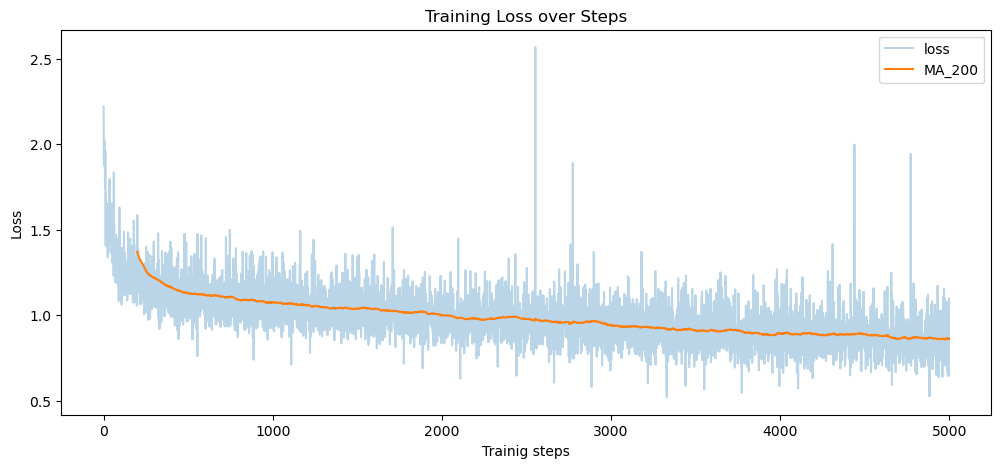

In [24]:
smooth = np.convolve(np.array(historic_loss, dtype=float), np.ones(LOG_EVERY)/LOG_EVERY, mode='valid')

plt.figure(figsize=(12,5))
plt.plot(historic_loss, label="loss", alpha=0.3)
plt.plot(range(LOG_EVERY-1, LOG_EVERY-1+len(smooth)), smooth, label=f"MA_{LOG_EVERY}")
plt.xlabel("Trainig steps")
plt.ylabel("Loss")
plt.title("Training Loss over Steps")
plt.legend()
plt.show()

# Evaluation

In [10]:
@torch.no_grad()
def karras_schedule(n, sigma_min, sigma_max, rho=7.0, device="cpu"):
    i = torch.linspace(0, 1, n, device=device)
    sigmas = (sigma_max**(1/rho) + i*(sigma_min**(1/rho) - sigma_max**(1/rho))) ** rho
    return torch.cat([sigmas, sigmas.new_zeros([1])])  # append 0

@torch.no_grad()
def edm_sample_impute(edm, x, cond_mask, n_steps=12, sigma_min=0.01, sigma_max=50.0):
    """
    x: [B,K,L] clean series (used to supply conditioned values)
    cond_mask: [B,K,L] 1 where values are conditioned/observed
    """
    B, K, L = x.shape
    cond_values = x * cond_mask

    # Initialize missing part with noise at sigma_max
    x_cur = torch.randn_like(x) * sigma_max
    x_cur = cond_mask * cond_values + (1 - cond_mask) * x_cur

    sigmas = karras_schedule(n_steps, sigma_min, sigma_max, rho=7.0, device=x.device)

    for j in range(n_steps):
        sigma = sigmas[j].expand(B)
        sigma_next = sigmas[j+1].expand(B)

        x_hat = edm(x_cur, sigma, cond_values, cond_mask)
        d = (x_cur - x_hat) / sigma[:, None, None]
        x_next = x_cur + (sigma_next - sigma)[:, None, None] * d

        # Re-apply conditioning constraint
        x_next = cond_mask * cond_values + (1 - cond_mask) * x_next
        x_cur = x_next

    return x_cur


In [11]:
def make_eval_masks(obs_mask, gt_mask=None, p_drop=0.2):
    obs_mask = obs_mask.float()

    if gt_mask is not None:
        target_mask = gt_mask.float().clamp(0, 1)
        cond_mask = (obs_mask - target_mask).clamp(0, 1)
    else:
        drop = (torch.rand_like(obs_mask) < p_drop).float()
        cond_mask = (obs_mask * (1 - drop)).clamp(0, 1)
        target_mask = (obs_mask - cond_mask).clamp(0, 1)

    return cond_mask, target_mask


In [12]:
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def eval_one_batch(edm, batch, n_steps=12, p_drop=0.2, sigma_min=0.01, sigma_max=50.0):
    edm.eval()
    x = batch["observed_data"].float()         # [B,K,L]
    obs_mask = batch["observed_mask"].float()  # [B,K,L]
    gt_mask = batch.get("gt_mask", None)
    if gt_mask is not None:
        gt_mask = gt_mask.float()

    cond_mask, target_mask = make_eval_masks(obs_mask, gt_mask=gt_mask, p_drop=p_drop)

    x_imp = edm_sample_impute(edm, x, cond_mask, n_steps=n_steps, sigma_min=sigma_min, sigma_max=sigma_max)

    # --- Metrics on withheld positions only
    diff = (x_imp - x)
    denom = target_mask.sum().clamp(min=1.0)
    mae = (diff.abs() * target_mask).sum() / denom
    rmse = torch.sqrt(((diff**2) * target_mask).sum() / denom)

    # Per-feature metrics
    K = x.shape[1]
    mae_k, rmse_k = [], []
    for k in range(K):
        tk = target_mask[:, k, :].sum().clamp(min=1.0)
        mae_k.append(((diff[:, k, :].abs() * target_mask[:, k, :]).sum() / tk).item())
        rmse_k.append(torch.sqrt(((diff[:, k, :]**2) * target_mask[:, k, :]).sum() / tk).item())

    # Extract withheld values for distribution plots
    true_vals = x[target_mask.bool()].cpu().numpy()
    imp_vals  = x_imp[target_mask.bool()].cpu().numpy()

    # Summary stats
    def stats(a):
        return {
            "mean": float(np.mean(a)),
            "std": float(np.std(a)),
            "q05": float(np.quantile(a, 0.05)),
            "q50": float(np.quantile(a, 0.50)),
            "q95": float(np.quantile(a, 0.95)),
        }

    out = {
        "mae": float(mae.item()),
        "rmse": float(rmse.item()),
        "mae_per_feature": mae_k,
        "rmse_per_feature": rmse_k,
        "true_stats": stats(true_vals) if true_vals.size else None,
        "imp_stats": stats(imp_vals) if imp_vals.size else None,
        "x": x, "x_imp": x_imp, "cond_mask": cond_mask, "target_mask": target_mask
    }
    return out

MAE: 0.9305940866470337 RMSE: 1.296976923942566
MAE per feature: [0.8309030532836914, 0.929470956325531, 0.9008671045303345, 0.9675295352935791, 1.0241994857788086]
RMSE per feature: [1.2905631065368652, 1.303640365600586, 1.2831363677978516, 1.2946875095367432, 1.31265389919281]
True withheld stats: {'mean': -0.0005707729142159224, 'std': 0.9883995652198792, 'q05': -1.4554238319396973, 'q50': 0.0020551211200654507, 'q95': 1.442596435546875}
Imputed withheld stats: {'mean': 0.005985043477267027, 'std': 0.8467324376106262, 'q05': -1.2824134826660156, 'q50': 0.011895387899130583, 'q95': 1.2635257542133322}


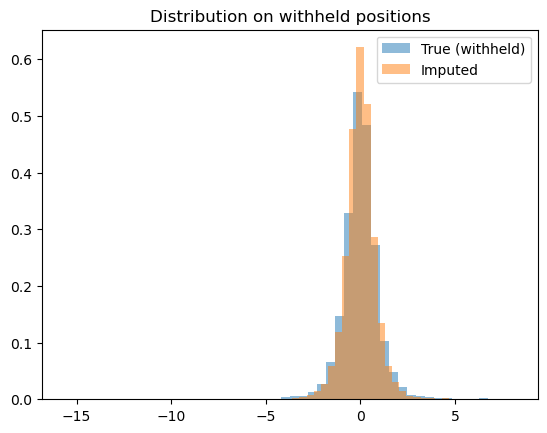

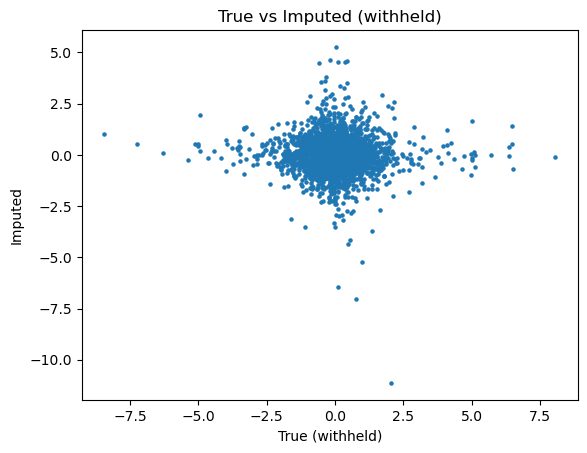

In [13]:
# Run on a batch
batch = next(iter(train_loader))
res = eval_one_batch(edm, batch, n_steps=100, p_drop=0.2)

print("MAE:", res["mae"], "RMSE:", res["rmse"])
print("MAE per feature:", res["mae_per_feature"])
print("RMSE per feature:", res["rmse_per_feature"])
print("True withheld stats:", res["true_stats"])
print("Imputed withheld stats:", res["imp_stats"])

# ---- Distribution plot (withheld positions)
true_vals = res["x"][res["target_mask"].bool()].cpu().numpy()
imp_vals  = res["x_imp"][res["target_mask"].bool()].cpu().numpy()

plt.figure()
plt.hist(true_vals, bins=50, alpha=0.5, density=True, label="True (withheld)")
plt.hist(imp_vals,  bins=50, alpha=0.5, density=True, label="Imputed")
plt.legend()
plt.title("Distribution on withheld positions")
plt.show()

# ---- Scatter plot true vs imputed (withheld)
plt.figure()
idx = np.random.choice(len(true_vals), size=min(3000, len(true_vals)), replace=False) if len(true_vals) > 0 else []
plt.scatter(true_vals[idx], imp_vals[idx], s=5)
plt.xlabel("True (withheld)")
plt.ylabel("Imputed")
plt.title("True vs Imputed (withheld)")
plt.show()


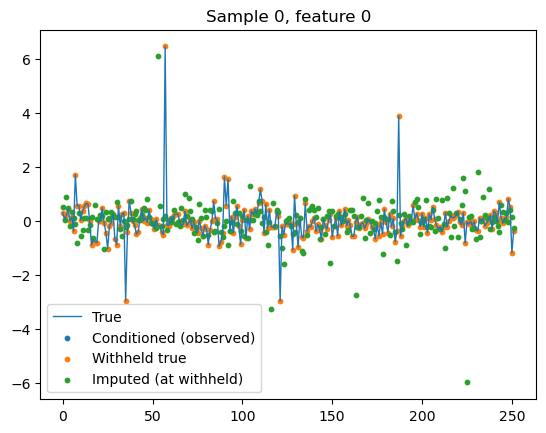

In [14]:
@torch.no_grad()
def plot_example(res, b=0, k=0):
    x = res["x"][b, k].cpu().numpy()
    x_imp = res["x_imp"][b, k].cpu().numpy()
    cond = res["cond_mask"][b, k].cpu().numpy().astype(bool)
    targ = res["target_mask"][b, k].cpu().numpy().astype(bool)

    t = np.arange(len(x))
    plt.figure()
    plt.plot(t, x, label="True", linewidth=1)
    plt.scatter(t[cond], x[cond], s=10, label="Conditioned (observed)")
    plt.scatter(t[targ], x[targ], s=10, label="Withheld true")
    plt.scatter(t[targ], x_imp[targ], s=10, label="Imputed (at withheld)")
    plt.legend()
    plt.title(f"Sample {b}, feature {k}")
    plt.show()

plot_example(res, b=0, k=0)
